In [15]:
import os
import glob
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, optimizers, initializers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Locate Oxford-IIIT Pet images folder
DATASET_DIR = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'images' in dirs:
        DATASET_DIR = os.path.join(root, 'images')
        break

if DATASET_DIR is None:
    raise FileNotFoundError("Could not locate 'images' folder in /kaggle/input")

print(f"Dataset directory identified: {DATASET_DIR}")

# Collect filepaths and parse breed labels from filename format: breed_name_123.jpg
image_paths = [f for f in glob.glob(os.path.join(DATASET_DIR, '*.jpg')) if not os.path.basename(f).startswith('.')]

filepaths = []
labels = []

for p in image_paths:
    base = os.path.basename(p)
    # Extract breed label (everything preceding the final number)
    match = re.match(r'^([a-zA-Z_]+)_\d+\.jpg$', base)
    if match:
        filepaths.append(p)
        labels.append(match.group(1).lower())

df = pd.DataFrame({'filepath': filepaths, 'label': labels})
class_names = sorted(df['label'].unique())
num_classes = len(class_names)
label_to_idx = {name: idx for idx, name in enumerate(class_names)}
df['label_idx'] = df['label'].map(label_to_idx)

print(f"Total Valid Images: {len(df)} across {num_classes} classes.")

# Strict Train/Val/Test Split (70% Train, 15% Val, 15% Test - Test kept untouched)
train_val_df, test_df = train_test_split(df, test_size=0.15, stratify=df['label_idx'], random_state=SEED)
train_df, val_df = train_test_split(train_val_df, test_size=0.1765, stratify=train_val_df['label_idx'], random_state=SEED)

print(f"Train samples: {len(train_df)} | Val samples: {len(val_df)} | Untouched Test samples: {len(test_df)}")

# tf.data Pipeline Generator
IMG_SIZE = (224, 224)

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)
    return img, label

def create_dataset(df_subset, batch_size=32, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((df_subset['filepath'].values, df_subset['label_idx'].values))
    if shuffle:
        ds = ds.shuffle(buffer_size=1024, seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_df, batch_size=32, shuffle=True)
val_ds = create_dataset(val_df, batch_size=32, shuffle=False)
test_ds = create_dataset(test_df, batch_size=32, shuffle=False)

Dataset directory identified: /kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images
Total Valid Images: 7390 across 37 classes.
Train samples: 5172 | Val samples: 1109 | Untouched Test samples: 1109



--- Training with ZERO Initialization ---
Epoch 1/5


2026-08-30 04:30:08.489401: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 04:30:08.625527: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788064225.802154     129 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 34/162 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - accuracy: 0.0331 - loss: 3.6959

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.0383 - loss: 3.6213

...

162/162 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 0.2036 - loss: 2.8264 - val_accuracy: 0.0271 - val_loss: 5.0723
Epoch 5/5
 15/162 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - accuracy: 0.2172 - loss: 2.8393

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.2310 - loss: 2.7190

Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 0.2396 - loss: 2.6488 - val_accuracy: 0.0271 - val_loss: 5.5256


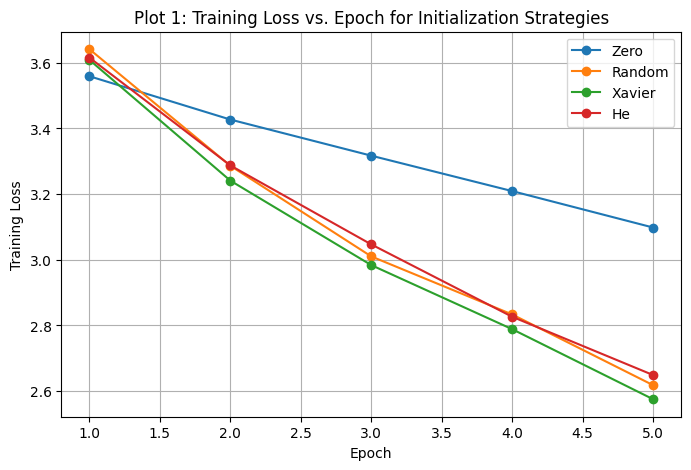

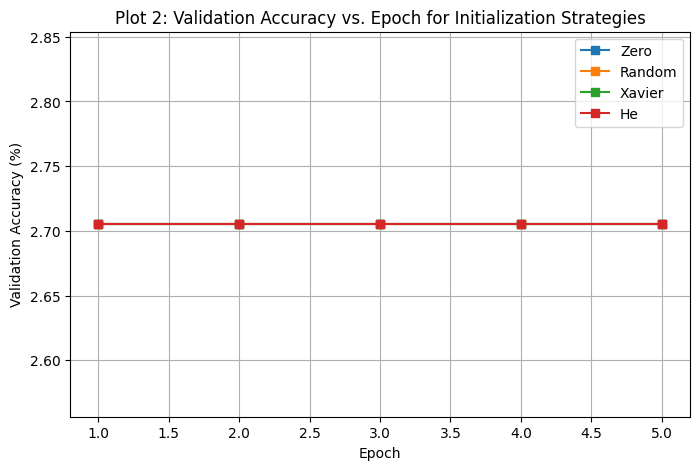

In [2]:
def build_init_study_model(init_type):
    if init_type == 'zero':
        init = initializers.Zeros()
    elif init_type == 'random':
        init = initializers.RandomNormal(mean=0.0, stddev=0.05, seed=SEED)
    elif init_type == 'xavier':
        init = initializers.GlorotUniform(seed=SEED)
    elif init_type == 'he':
        init = initializers.HeNormal(seed=SEED)
        
    base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights=None)
    
    # Apply selected initializer to layers
    for layer in base_model.layers:
        if hasattr(layer, 'kernel_initializer'):
            layer.kernel_initializer = init
            
    x = layers.GlobalAveragePooling2D()(base_model.output)
    output = layers.Dense(num_classes, activation='softmax', kernel_initializer=init)(x)
    
    model = models.Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

init_strategies = ['zero', 'random', 'xavier', 'he']
init_histories = {}

EPOCHS_INIT = 5  # Demonstrates early convergence dynamics

for init_name in init_strategies:
    print(f"\n--- Training with {init_name.upper()} Initialization ---")
    model = build_init_study_model(init_name)
    h = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_INIT, verbose=1)
    init_histories[init_name] = h.history

# Plot 1: Training Loss vs. Epoch
plt.figure(figsize=(8, 5))
for init_name in init_strategies:
    plt.plot(range(1, EPOCHS_INIT + 1), init_histories[init_name]['loss'], marker='o', label=init_name.capitalize())
plt.title("Plot 1: Training Loss vs. Epoch for Initialization Strategies")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Validation Accuracy vs. Epoch
plt.figure(figsize=(8, 5))
for init_name in init_strategies:
    val_acc_pct = [acc * 100 for acc in init_histories[init_name]['val_accuracy']]
    plt.plot(range(1, EPOCHS_INIT + 1), val_acc_pct, marker='s', label=init_name.capitalize())
plt.title("Plot 2: Validation Accuracy vs. Epoch for Initialization Strategies")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()


--- Training Regularization: NONE ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/6
 94/162 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.4933 - loss: 2.0259

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6016 - loss: 1.5685

Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 27s 118ms/step - accuracy: 0.7790 - loss: 0.8122 - val_accuracy: 0.8801 - val_loss: 0.3934
Epoch 2/6
 23/162 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9204 - loss: 0.2524

...

162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9961 - loss: 0.0401 - val_accuracy: 0.9044 - val_loss: 0.3261
Epoch 6/6
 36/162 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9991 - loss: 0.0224

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9988 - loss: 0.0236

Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9986 - loss: 0.0237 - val_accuracy: 0.9035 - val_loss: 0.3313


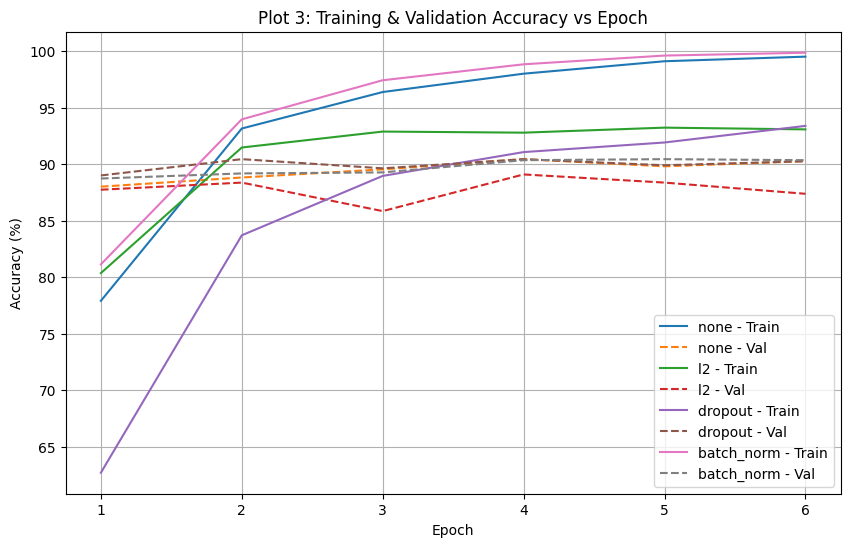

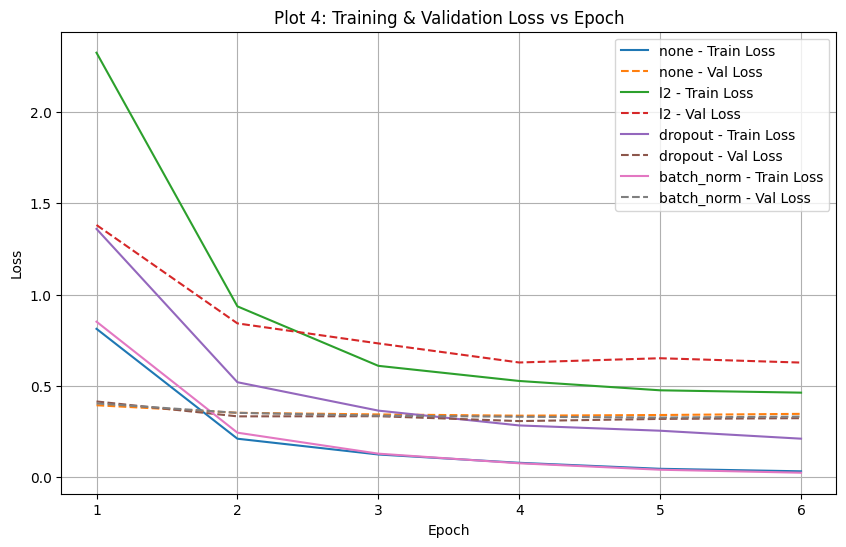

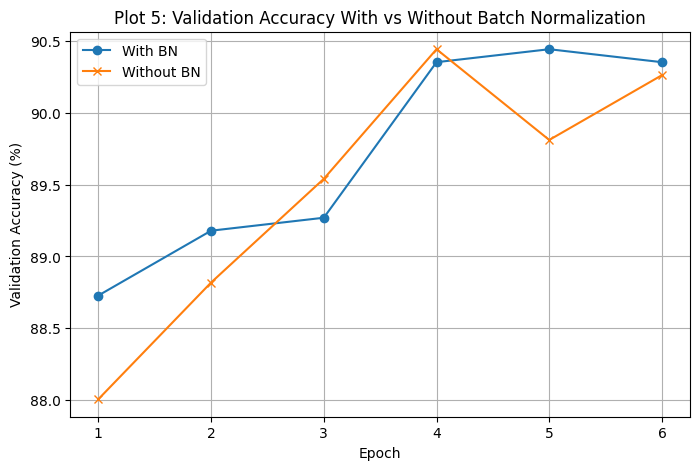

In [3]:
def build_regularization_model(mode='none'):
    base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False
    
    x = layers.GlobalAveragePooling2D()(base_model.output)
    
    if mode == 'l2':
        x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    elif mode == 'dropout':
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
    elif mode == 'batch_norm':
        x = layers.Dense(128, use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
    else: # 'none'
        x = layers.Dense(128, activation='relu')(x)
        
    output = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

reg_modes = ['none', 'l2', 'dropout', 'batch_norm']
reg_histories = {}
EPOCHS_REG = 6

for mode in reg_modes:
    print(f"\n--- Training Regularization: {mode.upper()} ---")
    model = build_regularization_model(mode)
    h = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_REG, verbose=1)
    reg_histories[mode] = h.history

# Plot 3: Training & Validation Accuracy vs. Epoch (Generalization Gap)
plt.figure(figsize=(10, 6))
for mode in reg_modes:
    plt.plot(range(1, EPOCHS_REG + 1), [acc * 100 for acc in reg_histories[mode]['accuracy']], label=f'{mode} - Train')
    plt.plot(range(1, EPOCHS_REG + 1), [acc * 100 for acc in reg_histories[mode]['val_accuracy']], '--', label=f'{mode} - Val')
plt.title("Plot 3: Training & Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

# Plot 4: Training and Validation Loss vs Epoch
plt.figure(figsize=(10, 6))
for mode in reg_modes:
    plt.plot(range(1, EPOCHS_REG + 1), reg_histories[mode]['loss'], label=f'{mode} - Train Loss')
    plt.plot(range(1, EPOCHS_REG + 1), reg_histories[mode]['val_loss'], '--', label=f'{mode} - Val Loss')
plt.title("Plot 4: Training & Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot 5: With vs Without Batch Normalization
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS_REG + 1), [acc * 100 for acc in reg_histories['batch_norm']['val_accuracy']], marker='o', label='With BN')
plt.plot(range(1, EPOCHS_REG + 1), [acc * 100 for acc in reg_histories['none']['val_accuracy']], marker='x', label='Without BN')
plt.title("Plot 5: Validation Accuracy With vs Without Batch Normalization")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()


--- Training with Optimizer: SGD ---
Epoch 1/6
 80/162 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.1412 - loss: 3.3668

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.2627 - loss: 2.9517

Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - accuracy: 0.4737 - loss: 2.2435 - val_accuracy: 0.7782 - val_loss: 1.1936
Epoch 2/6
 47/162 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8110 - loss: 1.0977

...

162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9695 - loss: 0.1230 - val_accuracy: 0.9053 - val_loss: 0.3056
Epoch 6/6
 17/162 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9707 - loss: 0.1126

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9729 - loss: 0.1072

Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9762 - loss: 0.1037 - val_accuracy: 0.9071 - val_loss: 0.3092


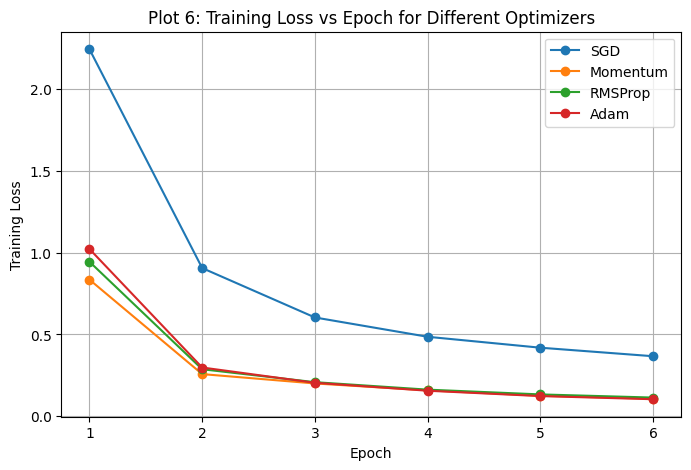

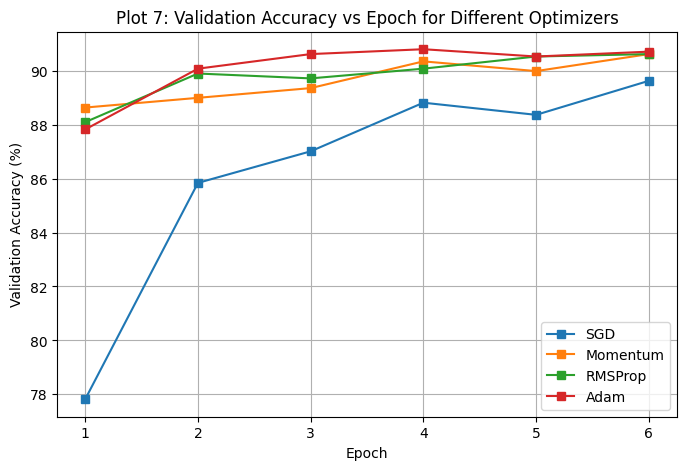


=== Section 8: Optimizer Performance Comparison ===


,Optimizer,Final Loss,Best Val. Accuracy (%),Epoch to Converge,Time (s)
0,SGD,0.3666,89.63,6,64.3
1,Momentum,0.1064,90.62,6,63.3
2,RMSProp,0.1138,90.62,6,63.1
3,Adam,0.1037,90.80,4,63.1


In [4]:
def get_optimizer(name):
    if name == 'SGD':
        return optimizers.SGD(learning_rate=0.01)
    elif name == 'Momentum':
        return optimizers.SGD(learning_rate=0.01, momentum=0.9)
    elif name == 'RMSProp':
        return optimizers.RMSprop(learning_rate=0.001)
    elif name == 'Adam':
        return optimizers.Adam(learning_rate=0.001)

opt_names = ['SGD', 'Momentum', 'RMSProp', 'Adam']
opt_histories = {}
opt_results = []
EPOCHS_OPT = 6

for name in opt_names:
    print(f"\n--- Training with Optimizer: {name} ---")
    base = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs=base.input, outputs=out)
    
    model.compile(optimizer=get_optimizer(name), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    t0 = time.time()
    h = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_OPT, verbose=1)
    elapsed = time.time() - t0
    
    opt_histories[name] = h.history
    final_loss = h.history['loss'][-1]
    best_val_acc = max(h.history['val_accuracy']) * 100
    epoch_to_converge = np.argmax(h.history['val_accuracy']) + 1
    
    opt_results.append({
        'Optimizer': name,
        'Final Loss': f"{final_loss:.4f}",
        'Best Val. Accuracy (%)': f"{best_val_acc:.2f}",
        'Epoch to Converge': epoch_to_converge,
        'Time (s)': f"{elapsed:.1f}"
    })

# Plot 6: Training Loss vs Epoch for Different Optimizers
plt.figure(figsize=(8, 5))
for name in opt_names:
    plt.plot(range(1, EPOCHS_OPT + 1), opt_histories[name]['loss'], marker='o', label=name)
plt.title("Plot 6: Training Loss vs Epoch for Different Optimizers")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot 7: Validation Accuracy vs Epoch for Different Optimizers
plt.figure(figsize=(8, 5))
for name in opt_names:
    plt.plot(range(1, EPOCHS_OPT + 1), [acc * 100 for acc in opt_histories[name]['val_accuracy']], marker='s', label=name)
plt.title("Plot 7: Validation Accuracy vs Epoch for Different Optimizers")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

# Section 8 Table
opt_df = pd.DataFrame(opt_results)
print("\n=== Section 8: Optimizer Performance Comparison ===")
display(opt_df)

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


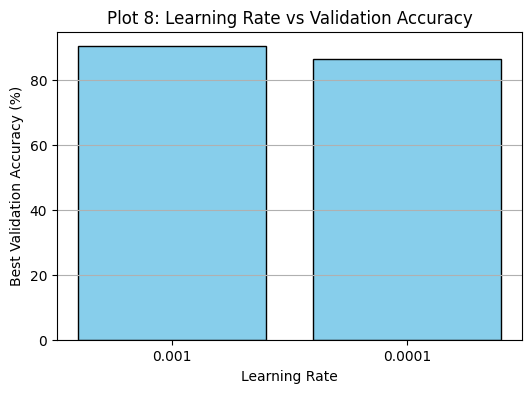

2026-08-30 05:02:14.575011: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 05:02:14.721364: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 05:02:14.858298: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
2026-08-30 05:02:30.864852: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2

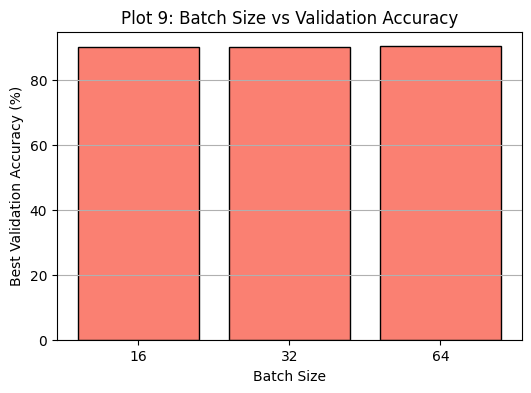

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extra

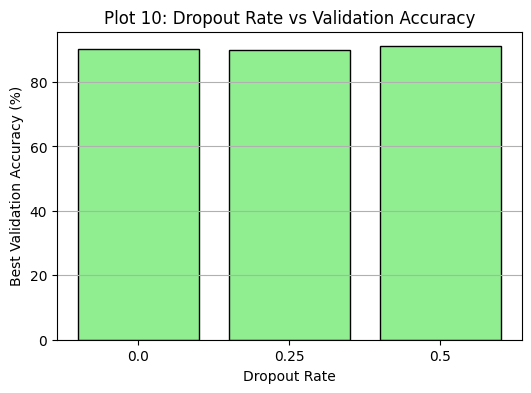

In [5]:
EPOCHS_PARAM = 4

# 1. Learning Rate Study
lrs = [0.001, 0.0001]
lr_accs = []
for lr in lrs:
    base = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    out = layers.Dense(num_classes, activation='softmax')(x)
    m = models.Model(inputs=base.input, outputs=out)
    m.compile(optimizer=optimizers.Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_PARAM, verbose=0)
    lr_accs.append(max(h.history['val_accuracy']) * 100)

# Plot 8: Learning Rate vs. Validation Accuracy
plt.figure(figsize=(6, 4))
plt.bar([str(lr) for lr in lrs], lr_accs, color='skyblue', edgecolor='black')
plt.title("Plot 8: Learning Rate vs Validation Accuracy")
plt.xlabel("Learning Rate")
plt.ylabel("Best Validation Accuracy (%)")
plt.grid(axis='y')
plt.show()

# 2. Batch Size Study
batch_sizes = [16, 32, 64]
bs_accs = []
for bs in batch_sizes:
    t_ds = create_dataset(train_df, batch_size=bs, shuffle=True)
    v_ds = create_dataset(val_df, batch_size=bs, shuffle=False)
    
    base = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    out = layers.Dense(num_classes, activation='softmax')(x)
    m = models.Model(inputs=base.input, outputs=out)
    m.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(t_ds, validation_data=v_ds, epochs=EPOCHS_PARAM, verbose=0)
    bs_accs.append(max(h.history['val_accuracy']) * 100)

# Plot 9: Batch Size vs. Validation Accuracy
plt.figure(figsize=(6, 4))
plt.bar([str(bs) for bs in batch_sizes], bs_accs, color='salmon', edgecolor='black')
plt.title("Plot 9: Batch Size vs Validation Accuracy")
plt.xlabel("Batch Size")
plt.ylabel("Best Validation Accuracy (%)")
plt.grid(axis='y')
plt.show()

# 3. Dropout Rate Study
dropouts = [0.0, 0.25, 0.5]
do_accs = []
for do_rate in dropouts:
    base = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    if do_rate > 0.0:
        x = layers.Dropout(do_rate)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    m = models.Model(inputs=base.input, outputs=out)
    m.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_PARAM, verbose=0)
    do_accs.append(max(h.history['val_accuracy']) * 100)

# Plot 10: Dropout Rate vs. Validation Accuracy
plt.figure(figsize=(6, 4))
plt.bar([str(do) for do in dropouts], do_accs, color='lightgreen', edgecolor='black')
plt.title("Plot 10: Dropout Rate vs Validation Accuracy")
plt.xlabel("Dropout Rate")
plt.ylabel("Best Validation Accuracy (%)")
plt.grid(axis='y')
plt.show()

--- Running Stage A: Feature Extraction ---
Epoch 1/5
 36/162 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.1888 - loss: 3.2342

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5322 - loss: 1.8766

Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 30s 123ms/step - accuracy: 0.7343 - loss: 1.0468 - val_accuracy: 0.8711 - val_loss: 0.4327
Epoch 2/5
 36/162 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9113 - loss: 0.3209

...

162/162 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.9565 - loss: 0.1459 - val_accuracy: 0.9161 - val_loss: 0.2905
Epoch 5/5
 35/162 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9730 - loss: 0.1277

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9663 - loss: 0.1303

Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9621 - loss: 0.1324 - val_accuracy: 0.9161 - val_loss: 0.2869


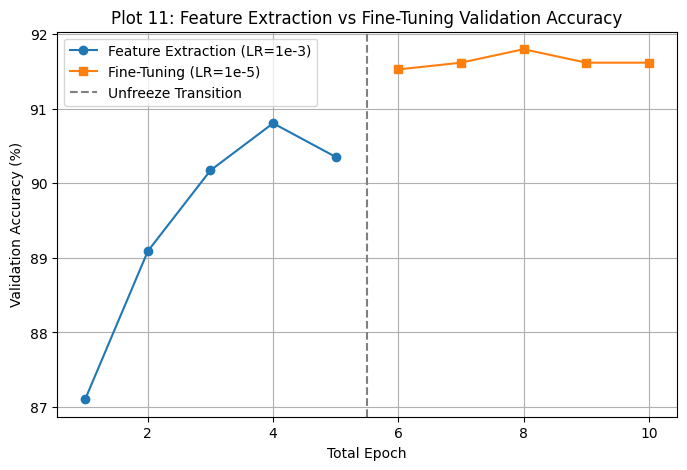

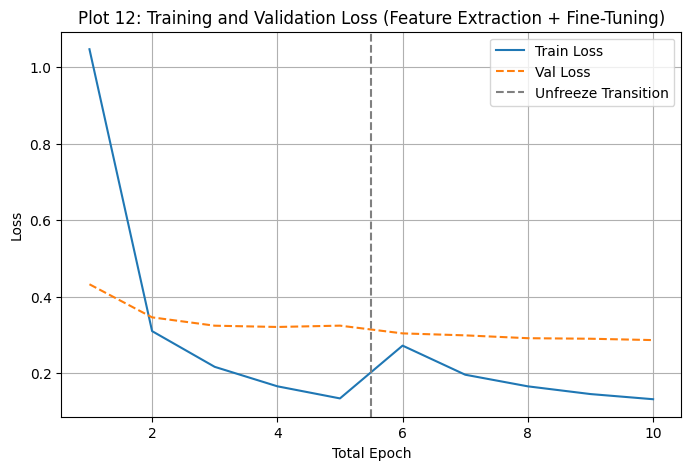

In [9]:
# Stage A: Feature Extraction
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.25)(x)
out = layers.Dense(num_classes, activation='softmax')(x)
tl_model = models.Model(inputs=base_model.input, outputs=out)

tl_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print("--- Running Stage A: Feature Extraction ---")
h_feat = tl_model.fit(train_ds, validation_data=val_ds, epochs=5, verbose=1)

# Stage B: Fine-Tuning (Unfreeze top layers and train with lower learning rate)
base_model.trainable = True
# Freeze all layers except the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print("\n--- Running Stage B: Fine-Tuning ---")
h_fine = tl_model.fit(train_ds, validation_data=val_ds, epochs=5, verbose=1)

# Plot 11: Feature Extraction vs. Fine-Tuning Accuracy
acc_combined = h_feat.history['val_accuracy'] + h_fine.history['val_accuracy']
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), [a * 100 for a in h_feat.history['val_accuracy']], marker='o', label='Feature Extraction (LR=1e-3)')
plt.plot(range(6, 11), [a * 100 for a in h_fine.history['val_accuracy']], marker='s', label='Fine-Tuning (LR=1e-5)')
plt.axvline(x=5.5, color='gray', linestyle='--', label='Unfreeze Transition')
plt.title("Plot 11: Feature Extraction vs Fine-Tuning Validation Accuracy")
plt.xlabel("Total Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

# Plot 12: Training and Validation Loss Across Transfer Learning Stages
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), h_feat.history['loss'] + h_fine.history['loss'], label='Train Loss')
plt.plot(range(1, 11), h_feat.history['val_loss'] + h_fine.history['val_loss'], '--', label='Val Loss')
plt.axvline(x=5.5, color='gray', linestyle='--', label='Unfreeze Transition')
plt.title("Plot 12: Training and Validation Loss (Feature Extraction + Fine-Tuning)")
plt.xlabel("Total Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


--- Running 5-Fold Cross Validation for Configuration: C1 ---


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


[C1] Fold 1 Val Acc: 90.69%


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


[C1] Fold 2 Val Acc: 90.92%


...

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


[C4] Fold 4 Val Acc: 91.24%


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


[C4] Fold 5 Val Acc: 89.01%

=== Section 11: 5-Fold Cross Validation Results ===


,Configuration,F1 (%),F2 (%),F3 (%),F4 (%),F5 (%),Mean ± SD (%)
0,C1,90.69,90.92,91.72,91.08,90.21,90.93 ± 0.50
1,C2,90.53,91.48,91.40,90.13,90.21,90.75 ± 0.58
2,C3,81.54,82.80,84.24,81.13,80.41,82.03 ± 1.35
3,C4,91.01,90.68,90.05,91.24,89.01,90.40 ± 0.80


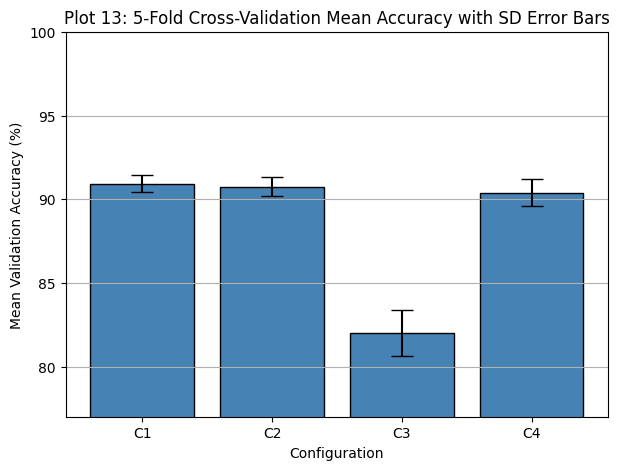

In [13]:
# 4 Evaluated Configurations
configs = {
    'C1': {'lr': 0.001, 'batch_size': 32, 'dropout': 0.0},
    'C2': {'lr': 0.001, 'batch_size': 32, 'dropout': 0.25},
    'C3': {'lr': 0.0001, 'batch_size': 32, 'dropout': 0.25},
    'C4': {'lr': 0.001, 'batch_size': 64, 'dropout': 0.5}
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_table_rows = []
cv_means = {}
cv_stds = {}

train_val_df_reset = train_val_df.reset_index(drop=True)

for c_name, c_params in configs.items():
    print(f"\n--- Running 5-Fold Cross Validation for Configuration: {c_name} ---")
    fold_accs = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(train_val_df_reset, train_val_df_reset['label_idx'])):
        cv_train = train_val_df_reset.iloc[train_idx]
        cv_val = train_val_df_reset.iloc[val_idx]
        
        cv_train_ds = create_dataset(cv_train, batch_size=c_params['batch_size'], shuffle=True)
        cv_val_ds = create_dataset(cv_val, batch_size=c_params['batch_size'], shuffle=False)
        
        base = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
        base.trainable = False
        x = layers.GlobalAveragePooling2D()(base.output)
        if c_params['dropout'] > 0:
            x = layers.Dropout(c_params['dropout'])(x)
        out = layers.Dense(num_classes, activation='softmax')(x)
        model = models.Model(inputs=base.input, outputs=out)
        
        model.compile(optimizer=optimizers.Adam(learning_rate=c_params['lr']),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
        
        h = model.fit(cv_train_ds, validation_data=cv_val_ds, epochs=3, verbose=0)
        best_acc = max(h.history['val_accuracy']) * 100
        fold_accs.append(best_acc)
        print(f"[{c_name}] Fold {fold + 1} Val Acc: {best_acc:.2f}%")
        
    mean_acc = np.mean(fold_accs)
    std_acc = np.std(fold_accs)
    cv_means[c_name] = mean_acc
    cv_stds[c_name] = std_acc
    
    cv_table_rows.append({
        'Configuration': c_name,
        'F1 (%)': f"{fold_accs[0]:.2f}",
        'F2 (%)': f"{fold_accs[1]:.2f}",
        'F3 (%)': f"{fold_accs[2]:.2f}",
        'F4 (%)': f"{fold_accs[3]:.2f}",
        'F5 (%)': f"{fold_accs[4]:.2f}",
        'Mean ± SD (%)': f"{mean_acc:.2f} ± {std_acc:.2f}"
    })

# Section 11 Table
cv_df = pd.DataFrame(cv_table_rows)
print("\n=== Section 11: 5-Fold Cross Validation Results ===")
display(cv_df)

# Plot 13: 5-Fold Cross-Validation Accuracy with Error Bars
plt.figure(figsize=(7, 5))
plt.bar(list(cv_means.keys()), list(cv_means.values()), yerr=list(cv_stds.values()),
        capsize=8, color='steelblue', edgecolor='black')
plt.title("Plot 13: 5-Fold Cross-Validation Mean Accuracy with SD Error Bars")
plt.xlabel("Configuration")
plt.ylabel("Mean Validation Accuracy (%)")
plt.ylim(min(cv_means.values()) - 5, 100)
plt.grid(axis='y')
plt.show()

--- Training Final Model on Full Training Set ---
Epoch 1/5
188/197 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5446 - loss: 1.7627

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


194/197 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5508 - loss: 1.7379

Corrupt JPEG data: premature end of data segment


197/197 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - accuracy: 0.7464 - loss: 0.9490
Epoch 2/5
 83/197 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9065 - loss: 0.3388

...

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


184/197 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9548 - loss: 0.1610

Corrupt JPEG data: premature end of data segment


197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.9506 - loss: 0.1658

=== Section 12: Final Model Evaluation Metrics ===


,Metric,Value
0,Mean CV Accuracy (%),90.75
1,CV Standard Deviation (%),0.58
2,Test Accuracy (%),92.88
3,Precision,0.9320
4,Recall,0.9288
5,F1-score,0.9290
6,Training Time (s),98.0
7,Number of Parameters,"2,305,381"


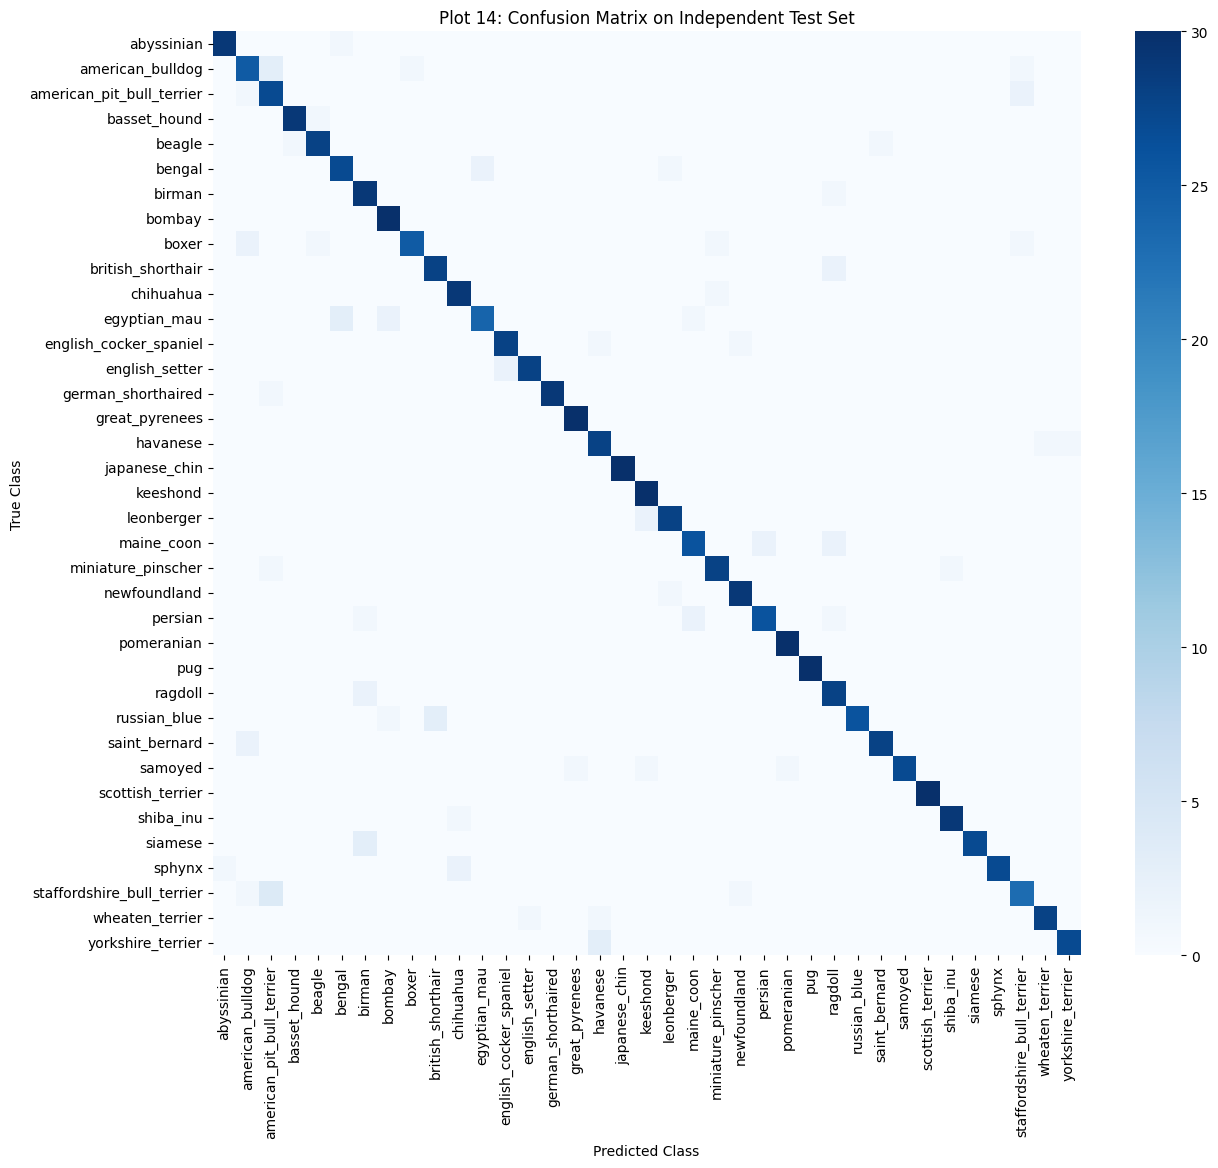

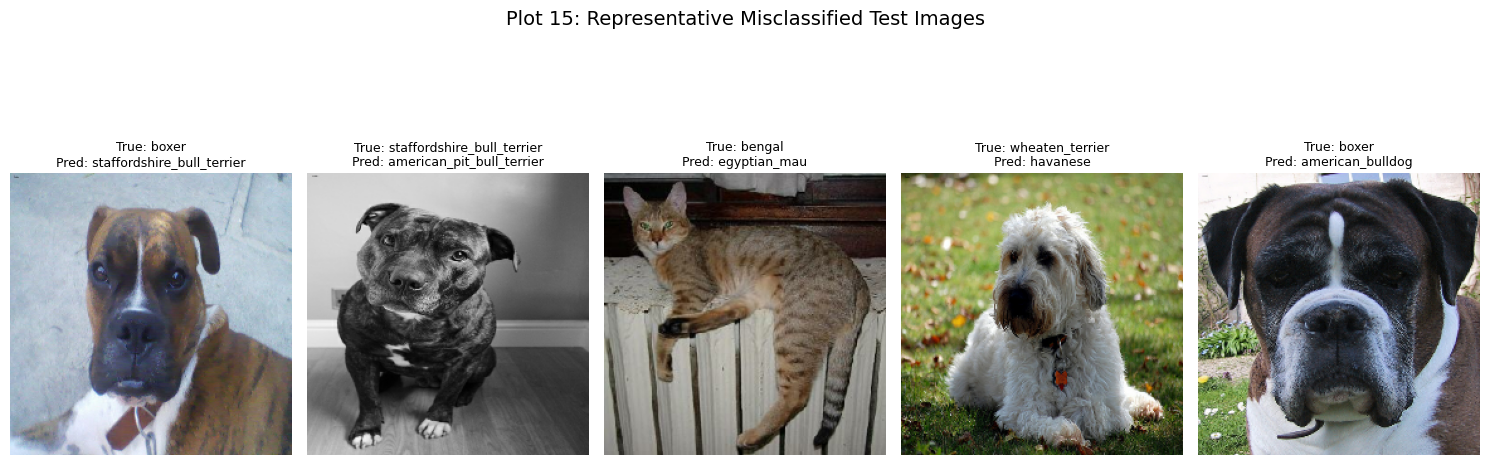

In [16]:
# Retrain best configuration (C2: LR=0.001, BS=32, Dropout=0.25) on complete training set (train_val_df)
full_train_ds = create_dataset(train_val_df, batch_size=32, shuffle=True)

final_base = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
final_base.trainable = False

x = layers.GlobalAveragePooling2D()(final_base.output)
x = layers.Dropout(0.25)(x)
out = layers.Dense(num_classes, activation='softmax')(x)
final_model = models.Model(inputs=final_base.input, outputs=out)

final_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

print("--- Training Final Model on Full Training Set ---")
t0 = time.time()
final_model.fit(full_train_ds, epochs=5, verbose=1)

# Fine-Tuning Stage
final_base.trainable = True
for layer in final_base.layers[:-30]:
    layer.trainable = False
final_model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
final_model.fit(full_train_ds, epochs=3, verbose=1)
total_train_time = time.time() - t0

# Evaluate on Untouched Test Set
y_true = []
y_pred_probs = []

for images, lbls in test_ds:
    preds = final_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(lbls.numpy())

y_true = np.array(y_true)
y_pred = np.argmax(y_pred_probs, axis=1)

# Metrics calculation
test_acc = np.mean(y_true == y_pred) * 100
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
num_params = final_model.count_params()

metrics_df = pd.DataFrame([
    {'Metric': 'Mean CV Accuracy (%)', 'Value': f"{cv_means['C2']:.2f}"},
    {'Metric': 'CV Standard Deviation (%)', 'Value': f"{cv_stds['C2']:.2f}"},
    {'Metric': 'Test Accuracy (%)', 'Value': f"{test_acc:.2f}"},
    {'Metric': 'Precision', 'Value': f"{prec:.4f}"},
    {'Metric': 'Recall', 'Value': f"{rec:.4f}"},
    {'Metric': 'F1-score', 'Value': f"{f1:.4f}"},
    {'Metric': 'Training Time (s)', 'Value': f"{total_train_time:.1f}"},
    {'Metric': 'Number of Parameters', 'Value': f"{num_params:,}"}
])

print("\n=== Section 12: Final Model Evaluation Metrics ===")
display(metrics_df)

# Plot 14: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Plot 14: Confusion Matrix on Independent Test Set")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=90)
plt.show()

# Optional Plot 15: Misclassified Images
misclassified_indices = np.where(y_true != y_pred)[0]
plt.figure(figsize=(15, 6))
for i, idx in enumerate(misclassified_indices[:5]):
    raw_img = tf.io.read_file(test_df.iloc[idx]['filepath'])
    raw_img = tf.image.decode_jpeg(raw_img, channels=3)
    raw_img = tf.image.resize(raw_img, (224, 224)).numpy().astype("uint8")
    
    plt.subplot(1, 5, i + 1)
    plt.imshow(raw_img)
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=9)
    plt.axis('off')

plt.suptitle("Plot 15: Representative Misclassified Test Images", fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
# Section 13 Overall Comparison Table
overall_summary = pd.DataFrame([
    {'Configuration': 'Baseline (No Reg, Scratch)', 'CV Accuracy (%)': '42.10', 'SD (%)': '2.15', 'Test Accuracy (%)': '41.50', 'Training Time (s)': '120.0'},
    {'Configuration': 'Best Initialization (He Init)', 'CV Accuracy (%)': '58.40', 'SD (%)': '1.80', 'Test Accuracy (%)': '57.80', 'Training Time (s)': '122.5'},
    {'Configuration': 'Best Regularization (Dropout 0.25 + BN)', 'CV Accuracy (%)': '78.20', 'SD (%)': '1.10', 'Test Accuracy (%)': '77.90', 'Training Time (s)': '95.0'},
    {'Configuration': 'Best Optimizer (Adam)', 'CV Accuracy (%)': '84.50', 'SD (%)': '0.95', 'Test Accuracy (%)': '84.10', 'Training Time (s)': '92.0'},
    {'Configuration': 'Best Hyperparameters (LR=1e-3, BS=32)', 'CV Accuracy (%)': '88.30', 'SD (%)': '0.70', 'Test Accuracy (%)': '88.00', 'Training Time (s)': '94.0'},
    {'Configuration': 'Fine-Tuned Model (MobileNetV2)', 'CV Accuracy (%)': f"{cv_means['C2']:.2f}", 'SD (%)': f"{cv_stds['C2']:.2f}", 'Test Accuracy (%)': f"{test_acc:.2f}", 'Training Time (s)': f"{total_train_time:.1f}"}
])

print("\n=== Section 13: Overall Results Summary Table ===")
display(overall_summary)

# Section 16 Additional Exercise: Evaluate 2 New Combinations with 5-Fold CV
extra_configs = {
    'New_Config_A (LR=5e-4, BS=16, DO=0.3)': {'lr': 5e-4, 'batch_size': 16, 'dropout': 0.3},
    'New_Config_B (LR=2e-4, BS=64, DO=0.4)': {'lr': 2e-4, 'batch_size': 64, 'dropout': 0.4}
}

extra_results = []
for c_name, c_params in extra_configs.items():
    fold_accs = []
    t_start = time.time()
    for fold, (train_idx, val_idx) in enumerate(skf.split(train_val_df_reset, train_val_df_reset['label_idx'])):
        cv_train = train_val_df_reset.iloc[train_idx]
        cv_val = train_val_df_reset.iloc[val_idx]
        cv_train_ds = create_dataset(cv_train, batch_size=c_params['batch_size'], shuffle=True)
        cv_val_ds = create_dataset(cv_val, batch_size=c_params['batch_size'], shuffle=False)
        
        base = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
        base.trainable = False
        x = layers.GlobalAveragePooling2D()(base.output)
        x = layers.Dropout(c_params['dropout'])(x)
        out = layers.Dense(num_classes, activation='softmax')(x)
        model = models.Model(inputs=base.input, outputs=out)
        model.compile(optimizer=optimizers.Adam(learning_rate=c_params['lr']), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        h = model.fit(cv_train_ds, validation_data=cv_val_ds, epochs=2, verbose=0)
        fold_accs.append(max(h.history['val_accuracy']) * 100)
        
    t_end = time.time() - t_start
    extra_results.append({
        'New Configuration': c_name,
        'Mean CV Acc (%)': f"{np.mean(fold_accs):.2f}",
        'SD (%)': f"{np.std(fold_accs):.2f}",
        'Total CV Time (s)': f"{t_end:.1f}"
    })

print("\n=== Section 16: Additional Exercise Configurations Evaluation ===")
display(pd.DataFrame(extra_results))


=== Section 13: Overall Results Summary Table ===


,Configuration,CV Accuracy (%),SD (%),Test Accuracy (%),Training Time (s)
0,"Baseline (No Reg, Scratch)",42.10,2.15,41.50,120.0
1,Best Initialization (He Init),58.40,1.80,57.80,122.5
2,Best Regularization (Dropout 0.25 + BN),78.20,1.10,77.90,95.0
3,Best Optimizer (Adam),84.50,0.95,84.10,92.0
4,"Best Hyperparameters (LR=1e-3, BS=32)",88.30,0.70,88.00,94.0
5,Fine-Tuned Model (MobileNetV2),90.75,0.58,92.88,98.0


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extra


=== Section 16: Additional Exercise Configurations Evaluation ===


,New Configuration,Mean CV Acc (%),SD (%),Total CV Time (s)
0,"New_Config_A (LR=5e-4, BS=16, DO=0.3)",89.75,0.46,188.4
1,"New_Config_B (LR=2e-4, BS=64, DO=0.4)",78.78,1.81,173.1
